In [1]:
# %cd /cephyr/users/felixnie/Alvis/NeuroCBIR/
# %cd /home/maia-user/NeuroCBIR/
%cd /mnt/alvis2/user/NeuroCBIR

/mnt/alvis2/user/NeuroCBIR


In [2]:
import pandas as pd
import numpy as np
import os
import logging

In [3]:

config = {
    "data_path": "/mnt/alvis2/mimer_user/batched_datasets",
    "output_dir": "dev/data_private/results/whole_brain/eval_cl64/",
    "dataset_index_file_name": "whole_brain/dataset_index.csv",
    "metadata_file_name": "combined_metadata.csv",
    
}

config.update({
    "embedding_file": "projected_embeddings.parquet",
    "project_filter": "",
    "class_column": "subject",
    "top_k_values": [
        1,
        5
    ],
    "bias_columns": [
        "partition",
        "project",
        # "disease",
        # "field_strength",
        # "manufacturer",
        # "model_name"
    ]
})


In [4]:
# Load and filter metadata
clinical_ds = pd.read_csv(os.path.join(config["data_path"], config["metadata_file_name"]))
if config.get("project_filter"):
    clinical_ds = clinical_ds.query(f"project == '{config['project_filter']}'").reset_index(drop=True)

# Load real features from parquet
emb_path = os.path.join(config["output_dir"], config["embedding_file"])  # e.g., "outputs/embeddings.parquet"
df_embs = pd.read_parquet(emb_path)

# Ensure GUID is string and joinable
df_embs["GUID"] = df_embs["GUID"].astype(str)
clinical_ds["GUID"] = clinical_ds["GUID"].astype(str)

# Merge on GUID
dataset = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")

# Filter out rows    
dataset = dataset.query("useable == 1").reset_index(drop=True)
# dataset = dataset.query("mislabel == 0").reset_index(drop=True)

dataset['subject'].replace('', pd.NA, inplace=True)
dataset = dataset.dropna(subset=['subject']).reset_index(drop=True)

# Convert embedding columns into a single 'features' column of vectors
embedding_cols = [col for col in df_embs.columns if col != "GUID"]
dataset["features"] = dataset[embedding_cols].apply(lambda row: row.to_numpy(), axis=1)

# Compute retrieval
retrieval_path = os.path.join(config["output_dir"], "retrieval.csv")
logging.info("Loading retrieved cases...")
retrieval_df = pd.read_csv(retrieval_path)

# Remove guid in retrieval_df that are not in dataset
# valid_guids = set(dataset["GUID"])
# retrieval_df = retrieval_df[retrieval_df["query"].isin(valid_guids)].reset_index(drop=True)


/tmp/ipykernel_65630/1209067068.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['subject'].replace('', pd.NA, inplace=True)


In [5]:
retrieval_df

,query,top1,top2,top3,top4,top5
0,11c21c8b-e574-466a-9459-656e09277e24,0aafbecd-21c7-403c-90f5-7d19b44c38e4,ae9cdbab-6e48-4cf2-9062-91560cdfa7e4,05f7a0b3-ae43-4da1-90ee-4a16e3736129,9dacc1e4-f52f-4b9e-9189-0db3c16b84a4,283ba3d9-0278-4a64-98a8-5f5d2be8cd24
1,0aafbecd-21c7-403c-90f5-7d19b44c38e4,11c21c8b-e574-466a-9459-656e09277e24,40764893-2efc-4aa0-9b42-576fcdae9884,9dacc1e4-f52f-4b9e-9189-0db3c16b84a4,283ba3d9-0278-4a64-98a8-5f5d2be8cd24,05f7a0b3-ae43-4da1-90ee-4a16e3736129
2,4c6770b6-fe89-4f78-91ee-f0ede611bd90,40764893-2efc-4aa0-9b42-576fcdae9884,5219950c-e68e-4bb0-9453-d81a97ad7024,9dacc1e4-f52f-4b9e-9189-0db3c16b84a4,0aafbecd-21c7-403c-90f5-7d19b44c38e4,05f7a0b3-ae43-4da1-90ee-4a16e3736129
3,40764893-2efc-4aa0-9b42-576fcdae9884,4c6770b6-fe89-4f78-91ee-f0ede611bd90,5219950c-e68e-4bb0-9453-d81a97ad7024,0aafbecd-21c7-403c-90f5-7d19b44c38e4,9dacc1e4-f52f-4b9e-9189-0db3c16b84a4,11c21c8b-e574-466a-9459-656e09277e24
4,9dacc1e4-f52f-4b9e-9189-0db3c16b84a4,5219950c-e68e-4bb0-9453-d81a97ad7024,0aafbecd-21c7-403c-90f5-7d19b44c38e4,11c21c8b-e574-466a-9459-656e09277e24,4c6770b6-fe89-4f78-91ee-f0ede611bd90,40764893-2efc-4aa0-9b42-576fcdae9884
...,...,...,...,...,...,...
26055,slim_31055_1,slim_31055_3,OAS30317_MR_d0088,27378aa1-5904-4e27-98d5-9b57aa15be11,2554d15d-3f71-4686-9453-234b11b5b544,314a621a-b557-448a-93ab-0f25bdb574e4
26056,slim_31055_3,slim_31055_1,slim_25764_2,slim_30990_1,OAS30539_MR_d0640,slim_30783_1
26057,slim_31056_1,slim_31056_3,4818977e-79fd-443e-9d23-9cdbfeb19239,0c6ad1a8-3668-4bf1-9b20-64274cf6e9d9,2d053179-a7f7-44e4-97e1-541c93f4d839,35d5dc62-59e9-4c2a-9c55-6faca6c759d9
26058,slim_31056_3,slim_31056_1,I269360,I169219,slim_30930_1,I195590


In [6]:
# 1. Build a lookup dictionary: GUID → subject
lookup = clinical_ds.set_index("GUID")["subject"]

# 2. Replace GUIDs in every column of retrieval_df using the lookup
retrieval_subject_df = retrieval_df.map(lambda x: lookup.get(x, x))


In [7]:
retrieval_subject_df

,query,top1,top2,top3,top4,top5
0,002_S_0295,002_S_0295,002_S_0295,002_S_0295,002_S_0295,002_S_0295
1,002_S_0295,002_S_0295,002_S_0295,002_S_0295,002_S_0295,002_S_0295
2,002_S_0295,002_S_0295,002_S_0295,002_S_0295,002_S_0295,002_S_0295
3,002_S_0295,002_S_0295,002_S_0295,002_S_0295,002_S_0295,002_S_0295
4,002_S_0295,002_S_0295,002_S_0295,002_S_0295,002_S_0295,002_S_0295
...,...,...,...,...,...,...
26055,31055,31055,OAS30317,002_S_0954,002_S_0954,002_S_0954
26056,31055,31055,25764,30990,OAS30539,30783
26057,31056,31056,082_S_1256,082_S_1256,082_S_1256,082_S_1256
26058,31056,31056,904,904,30930,904


In [8]:
k = 5

# Count how many times each subject appears in clinical_ds
subject_counts = dataset["subject"].value_counts()

# Map each query to its frequency
query_counts = retrieval_subject_df["query"].map(subject_counts).fillna(0)
valid_mask = query_counts >= k + 1  # +1 to account for the query itself

        


In [9]:
top_cols = ["top1", "top2", "top3", "top4", "top5"][0:k]

# Check row by row: are ALL top-k equal to the query subject?
same_subject_mask = retrieval_subject_df[top_cols].eq(
    retrieval_subject_df["query"], axis=0
).all(axis=1)

# Valid rows where query subject has at least k occurrences
invalid_rows = retrieval_subject_df[valid_mask & ~same_subject_mask]



In [10]:
invalid_rows

,query,top1,top2,top3,top4,top5
1249,006_S_1130,006_S_0521,006_S_1130,006_S_1130,006_S_1130,006_S_1130
1250,006_S_1130,006_S_1130,006_S_0521,006_S_1130,006_S_1130,006_S_1130
1253,006_S_1130,006_S_0521,006_S_1130,006_S_1130,006_S_1130,006_S_1130
1254,006_S_1130,006_S_1130,006_S_1130,006_S_1130,006_S_0521,006_S_1130
1255,006_S_1130,006_S_0521,006_S_1130,006_S_1130,006_S_1130,006_S_1130
1258,006_S_1130,006_S_1130,006_S_1130,006_S_1130,006_S_0521,006_S_1130
5866,023_S_1190,OAS30676,002_S_0559,OAS30676,OAS30676,OAS30676
5887,023_S_1190,023_S_1190,023_S_1190,023_S_1190,041_S_4877,041_S_4877
5888,023_S_1190,023_S_1190,023_S_1190,041_S_4877,041_S_4877,041_S_4877
7235,029_S_4385,029_S_4385,029_S_4385,029_S_4385,137_S_4466,029_S_4385


In [11]:
i = invalid_rows.index[0]
print(retrieval_df.iloc[i], retrieval_subject_df.iloc[i], subject_counts[i])

query    162a3436-ea08-461b-9399-c77772f22179
top1     280cfd46-270d-40f8-99a1-4fdf56704151
top2     2baca203-a757-4d0f-9813-23681aa9c561
top3     3232d255-f9b8-451c-94c9-8d1b4d764304
top4     a0d11701-572c-48e0-9fc5-4b53b591b100
top5     6744a7b8-49ff-4644-9f7e-9a22f2411571
Name: 1249, dtype: object query    006_S_1130
top1     006_S_0521
top2     006_S_1130
top3     006_S_1130
top4     006_S_1130
top5     006_S_1130
Name: 1249, dtype: object 8


/tmp/ipykernel_65630/1035102205.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(retrieval_df.iloc[i], retrieval_subject_df.iloc[i], subject_counts[i])


In [12]:
def inspect_invalid_case(i):
    print("\n================ INVALID CASE ================\n")
    
    # Query subject
    query_subj = retrieval_subject_df.loc[i, "query"]
    print("Query subject:", query_subj)
    print("Query guid:", retrieval_df.loc[i, "query"])
    print("Subject count:", subject_counts.get(query_subj, 0))
    
    # Retrieved subjects
    print("\nRetrieved top-k subjects:")
    print(retrieval_subject_df.loc[i, top_cols])
    
    # Original GUIDs (for debugging mapping)
    print("\nOriginal GUIDs in retrieval_df:")
    print(retrieval_df.loc[i])
    
    # Compact table view
    row_display = pd.DataFrame({
        "position": ["query"] + top_cols,
        "subject": [
            retrieval_subject_df.loc[i, "query"],
            retrieval_subject_df.loc[i, "top1"],
            retrieval_subject_df.loc[i, "top2"],
            retrieval_subject_df.loc[i, "top3"],
            retrieval_subject_df.loc[i, "top4"],
            retrieval_subject_df.loc[i, "top5"],
        ]
    })
    
    print("\nCompact view:")
    print(row_display)
    print("\n=============================================\n")

# ---------------------------------------------------------
# 6. Inspect first invalid case (if any)
# ---------------------------------------------------------
if len(invalid_rows) > 0:
    first_invalid_index = invalid_rows.index[0]
    inspect_invalid_case(first_invalid_index)
else:
    print("No invalid rows found.")


================ INVALID CASE ================

Query subject: 006_S_1130
Query guid: 162a3436-ea08-461b-9399-c77772f22179
Subject count: 17

Retrieved top-k subjects:
top1    006_S_0521
top2    006_S_1130
top3    006_S_1130
top4    006_S_1130
top5    006_S_1130
Name: 1249, dtype: object

Original GUIDs in retrieval_df:
query    162a3436-ea08-461b-9399-c77772f22179
top1     280cfd46-270d-40f8-99a1-4fdf56704151
top2     2baca203-a757-4d0f-9813-23681aa9c561
top3     3232d255-f9b8-451c-94c9-8d1b4d764304
top4     a0d11701-572c-48e0-9fc5-4b53b591b100
top5     6744a7b8-49ff-4644-9f7e-9a22f2411571
Name: 1249, dtype: object

Compact view:
  position     subject
0    query  006_S_1130
1     top1  006_S_0521
2     top2  006_S_1130
3     top3  006_S_1130
4     top4  006_S_1130
5     top5  006_S_1130




Number of invalid rows: 45
1194


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:15<00:00,  7.82s/it]


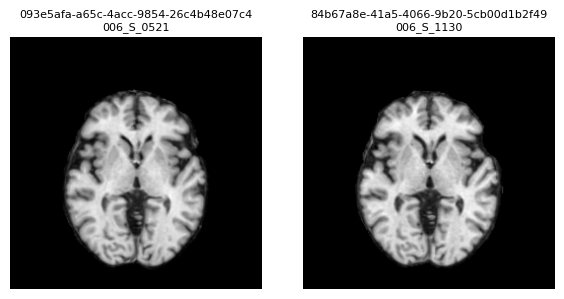

1249


100%|██████████| 2/2 [00:12<00:00,  6.06s/it]


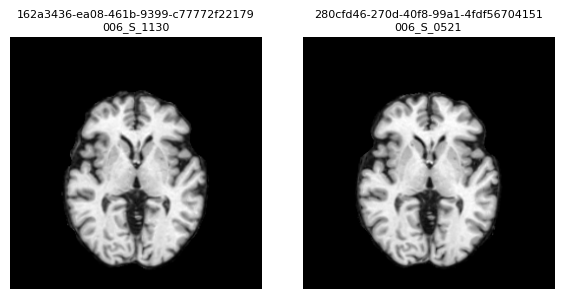

5866


100%|██████████| 2/2 [00:11<00:00,  5.73s/it]


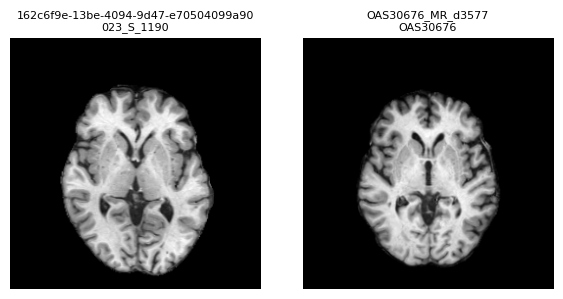

7061


100%|██████████| 2/2 [00:11<00:00,  5.82s/it]


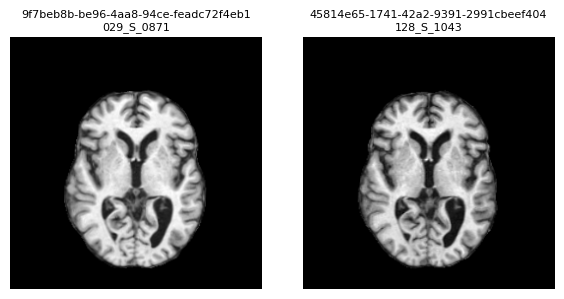

11424


100%|██████████| 2/2 [00:11<00:00,  5.94s/it]


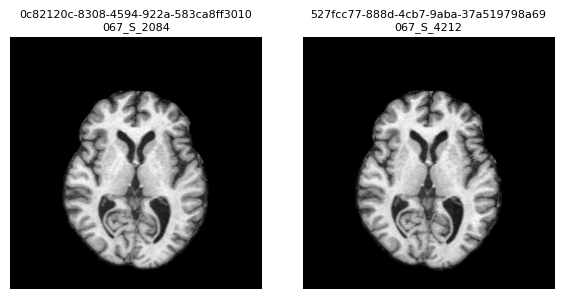

11521


100%|██████████| 2/2 [00:11<00:00,  5.92s/it]


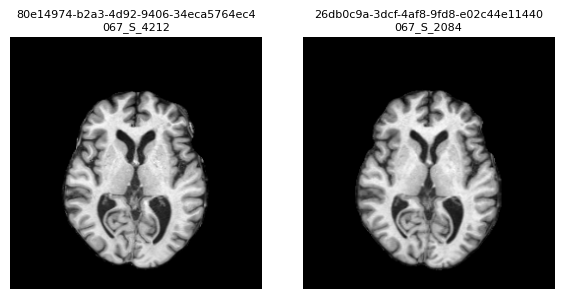

17025


100%|██████████| 2/2 [00:11<00:00,  5.99s/it]


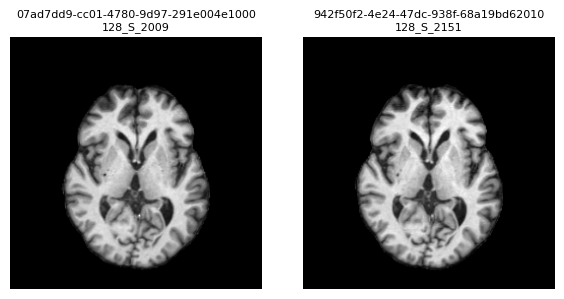

17088


100%|██████████| 2/2 [00:06<00:00,  3.36s/it]


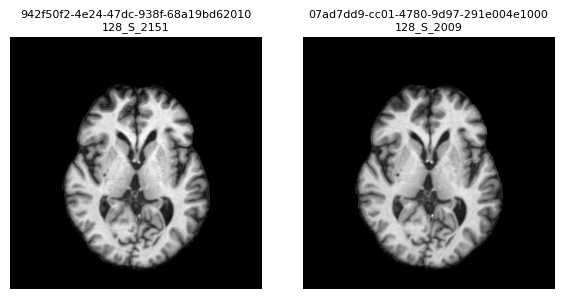

19599


100%|██████████| 2/2 [00:11<00:00,  5.75s/it]


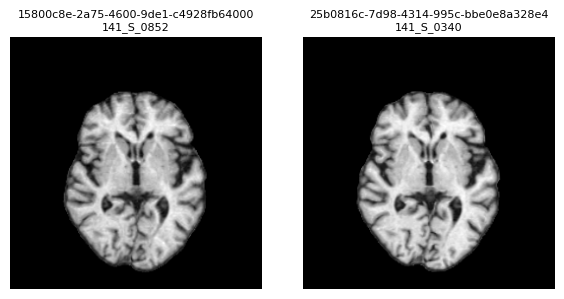

20435


100%|██████████| 2/2 [00:13<00:00,  6.55s/it]


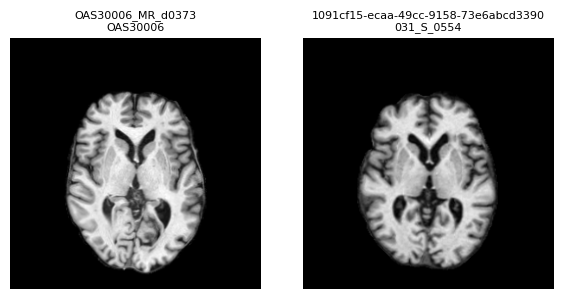

21032


100%|██████████| 2/2 [00:06<00:00,  3.26s/it]


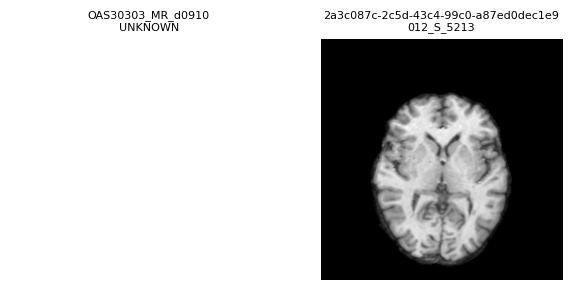

21104


100%|██████████| 2/2 [00:12<00:00,  6.19s/it]


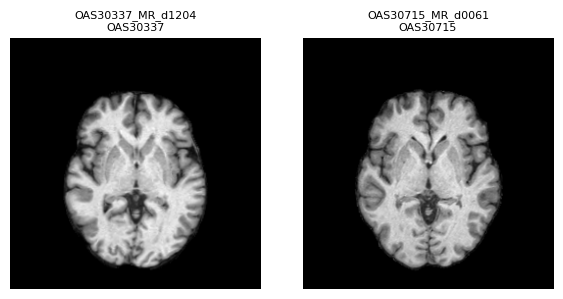

24031


100%|██████████| 2/2 [00:11<00:00,  5.71s/it]


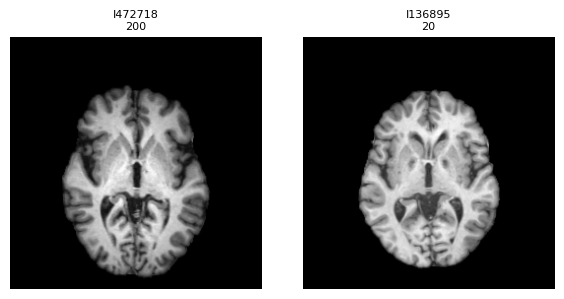

24108


100%|██████████| 2/2 [00:15<00:00,  7.61s/it]


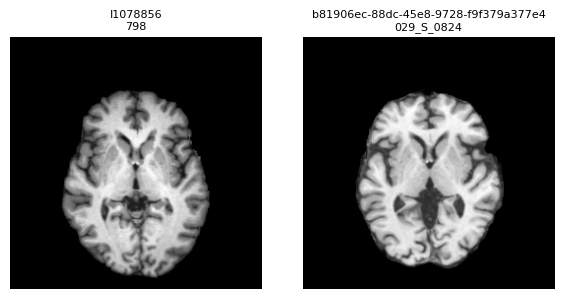

24590


100%|██████████| 2/2 [00:12<00:00,  6.36s/it]


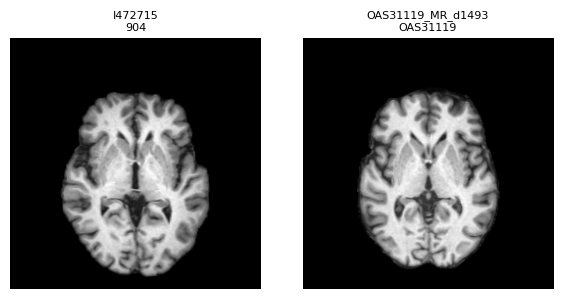

25093


100%|██████████| 2/2 [00:10<00:00,  5.46s/it]


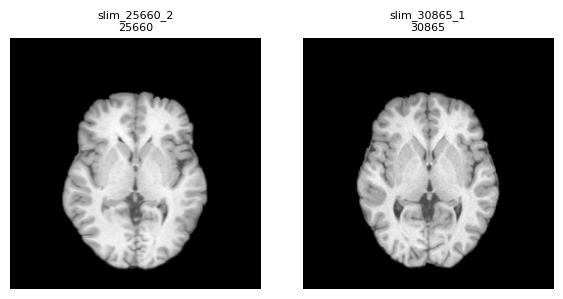

25094


100%|██████████| 2/2 [00:11<00:00,  5.89s/it]


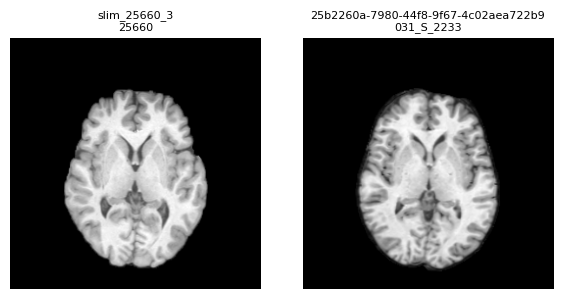

25146


100%|██████████| 2/2 [00:12<00:00,  6.06s/it]


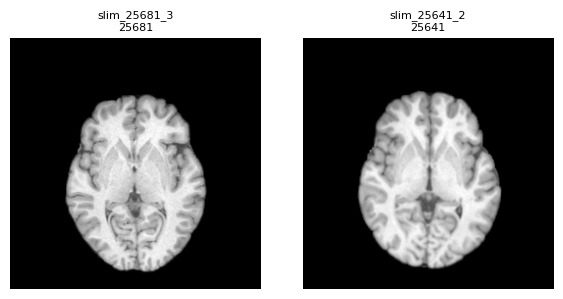

25225


100%|██████████| 2/2 [00:13<00:00,  6.59s/it]


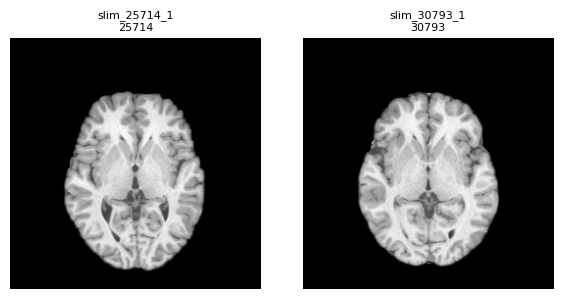

25226


100%|██████████| 2/2 [00:12<00:00,  6.18s/it]


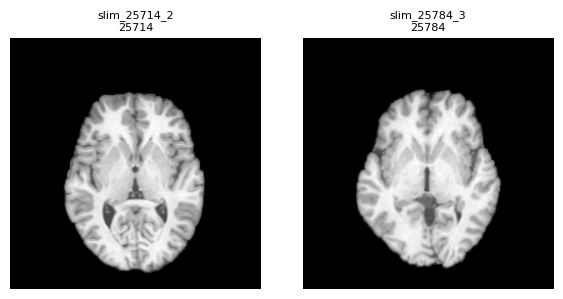

25262


100%|██████████| 2/2 [00:14<00:00,  7.24s/it]


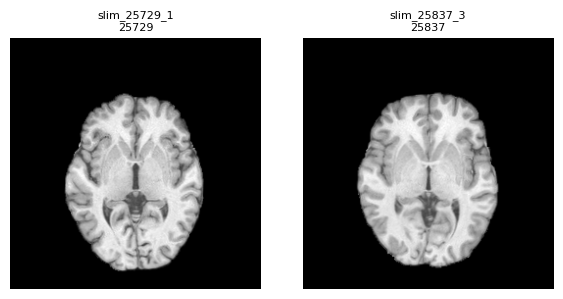

25263


100%|██████████| 2/2 [00:17<00:00,  8.80s/it]


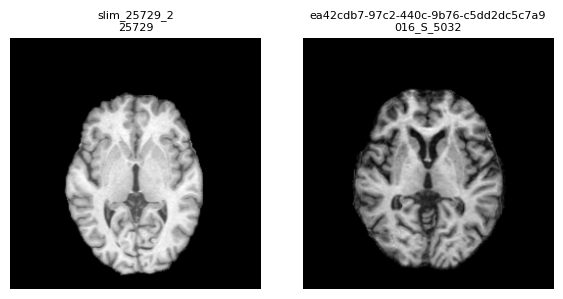

25393


100%|██████████| 2/2 [00:14<00:00,  7.38s/it]


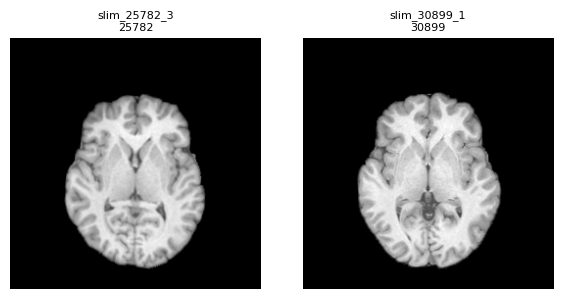

25436


100%|██████████| 2/2 [00:12<00:00,  6.40s/it]


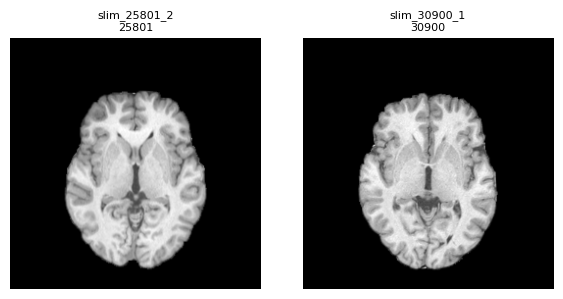

25437


100%|██████████| 2/2 [00:12<00:00,  6.29s/it]


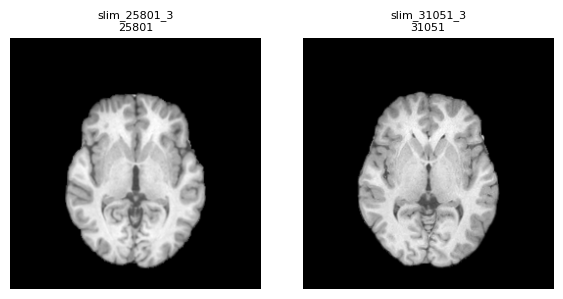

25461


100%|██████████| 2/2 [00:20<00:00, 10.25s/it]


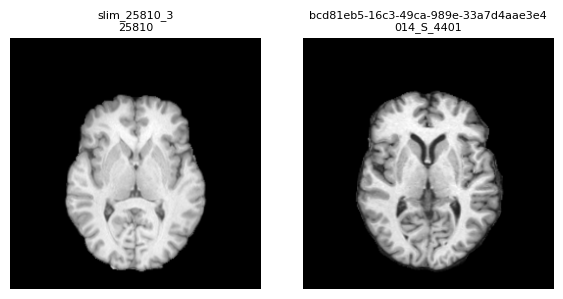

25652


100%|██████████| 2/2 [00:15<00:00,  7.86s/it]


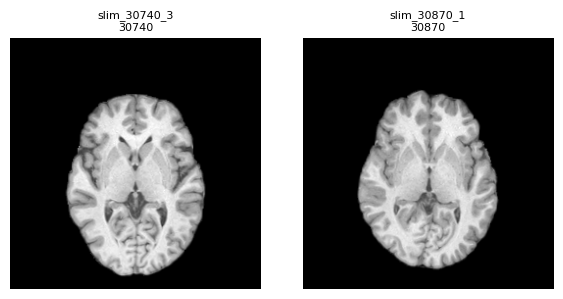

25725


100%|██████████| 2/2 [00:15<00:00,  7.75s/it]


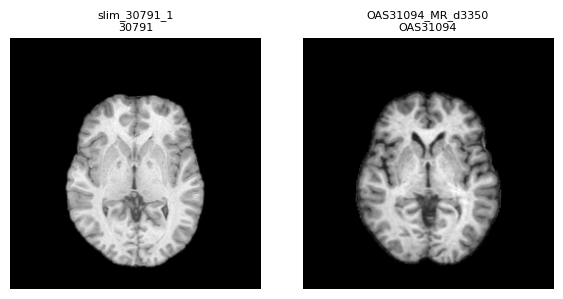

25726


100%|██████████| 2/2 [00:12<00:00,  6.15s/it]


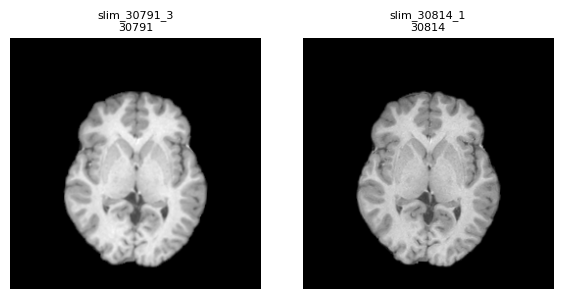

25823


100%|██████████| 2/2 [00:12<00:00,  6.48s/it]


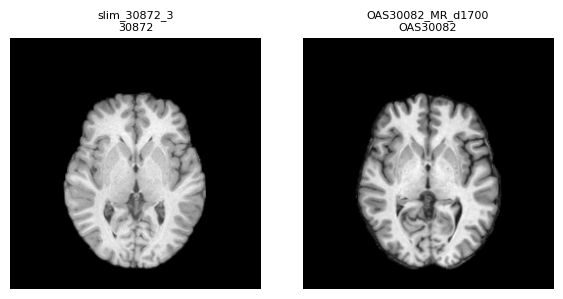

25888


100%|██████████| 2/2 [00:12<00:00,  6.29s/it]


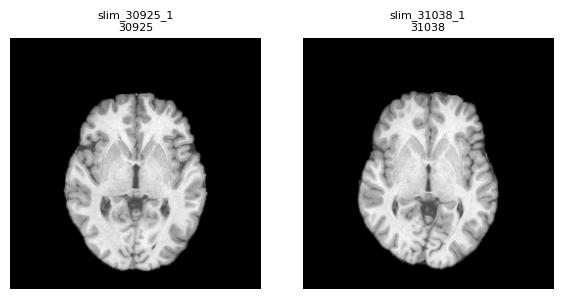

25889


100%|██████████| 2/2 [00:12<00:00,  6.28s/it]


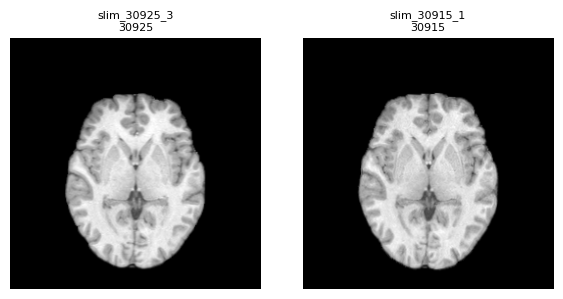

25960


100%|██████████| 2/2 [00:14<00:00,  7.22s/it]


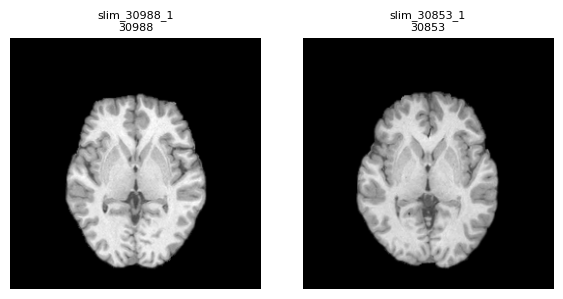

25961


100%|██████████| 2/2 [00:13<00:00,  6.78s/it]


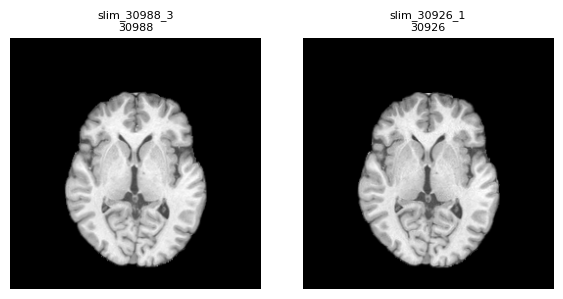

26033


100%|██████████| 2/2 [00:15<00:00,  7.53s/it]


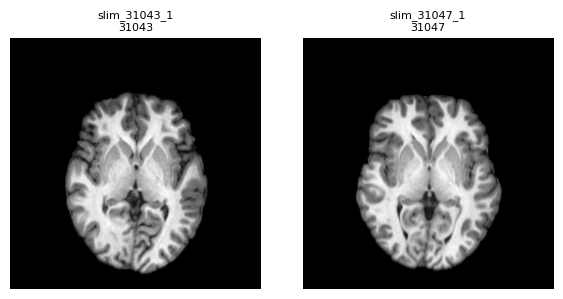

26034


100%|██████████| 2/2 [00:13<00:00,  6.80s/it]


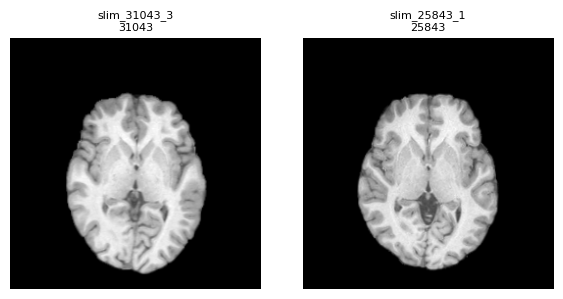

26037


100%|██████████| 2/2 [00:11<00:00,  5.89s/it]


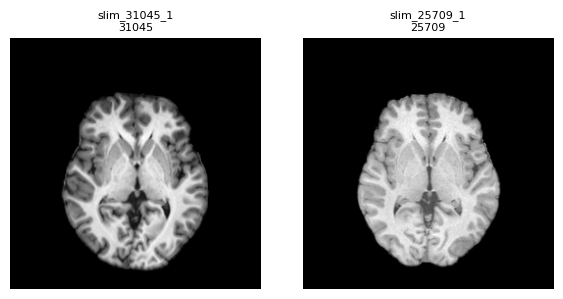

26038


100%|██████████| 2/2 [00:14<00:00,  7.07s/it]


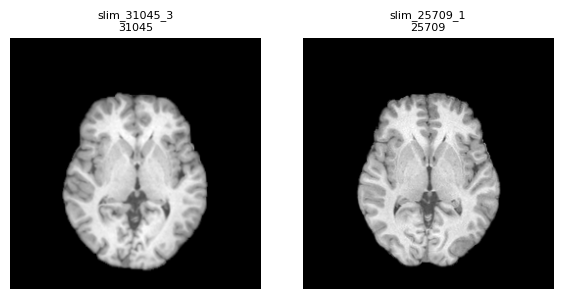

26054


100%|██████████| 2/2 [00:12<00:00,  6.04s/it]


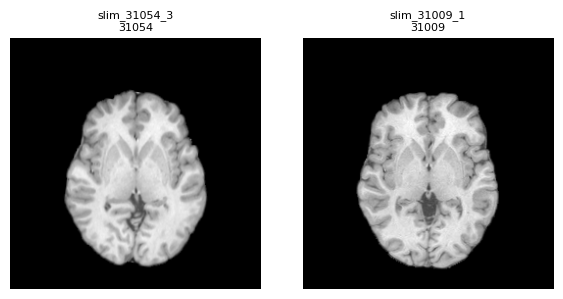

In [14]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

# ----------------------------
# Parameters
# ----------------------------
k = 1
top_cols = ["top1", "top2", "top3", "top4", "top5"][0:k]

# ----------------------------
# 1. Count subjects and identify valid queries
# ----------------------------
subject_counts = dataset["subject"].value_counts()
query_counts = retrieval_subject_df["query"].map(subject_counts).fillna(0)
valid_mask = query_counts >= k + 1  # Queries with at least k occurrences

# ----------------------------
# 2. Identify inconsistent rows (invalid ones)
# ----------------------------
same_subject_mask = retrieval_subject_df[top_cols].eq(
    retrieval_subject_df["query"], axis=0
).all(axis=1)

invalid_rows = retrieval_subject_df[valid_mask & ~same_subject_mask]
print(f"Number of invalid rows: {len(invalid_rows)}")

# ----------------------------
# 3. Map GUID -> subject & brain path
# ----------------------------
sub_df = dataset.set_index("GUID")[["subject", "brain"]]

# ----------------------------
# 4. Function to plot one invalid row
# ----------------------------
def plot_invalid_row(row_index):
    base_data_path = "/mnt/kth_cbh/fenda/Datasets"

    guids = [retrieval_df.loc[row_index, "query"]] + \
            [retrieval_df.loc[row_index, c] for c in top_cols]

    subjects = []
    paths = []
    for g in guids:
        if g in sub_df.index:
            subjects.append(sub_df.loc[g, "subject"])
            paths.append(sub_df.loc[g, "brain"])
        else:
            subjects.append("UNKNOWN")
            paths.append(None)

    images = []
    for p in tqdm(paths):
        if p is None:
            images.append(None)
            continue
        p = os.path.join(base_data_path, p)
        img = nib.load(p).get_fdata()
        mid_z = img.shape[1] // 2
        images.append(img[:, mid_z, :])

    fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3))
    for ax, uid, subj, img in zip(axes, guids, subjects, images):
        if img is not None:
            ax.imshow(np.rot90(img), cmap="gray")
        ax.axis("off")
        ax.set_title(f"{uid}\n{subj}", fontsize=8)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 5. Plot all invalid rows
# ----------------------------
previous_cases = set()
for idx in invalid_rows.index:
    # Plot only non repeated unique cases
    if tuple(invalid_rows.loc[idx].unique()) in previous_cases:
        continue
    previous_cases.add(tuple(invalid_rows.loc[idx].unique()))
    
    print(idx)
    plot_invalid_row(idx)
